### **Evaluating Classification Models**

We used a **10% sample to apply Bertopic**, grouping the topics into two categories - **relevant and irrelevant**.

After that, we trained a classification model and applied it to the rest of the dataset.

Models Used: Decision_Tree, KNN, Logistic_Regression

In [24]:
path_results = "classification_models/results"
models = ["Decision_Tree_(reduced).txt", "KNN_(reduced).txt", "Logistic_Regression_(reduced).txt"]

In [ ]:
results = [[] for _ in models]
for i,model in enumerate(models):
    try:
        with open(f"{path_results}/{model}", "r") as file:
            for line in file:
                if "weighted avg" in line:
                    parts = line.split() 
                    f1_score = parts[4] 
                    results[i].append(float(f1_score))
    except FileNotFoundError:
        print(f"Arquivo não encontrado para o modelo '{model}'. Pulando.")
    except IndexError:
        print(f"Erro de formatação de linha no arquivo '{model}'. Linha: {line.strip()}")

[[0.793, 0.797, 0.796, 0.783, 0.782], [0.818, 0.824, 0.823, 0.815, 0.815], [0.692, 0.699, 0.695, 0.695, 0.695]]


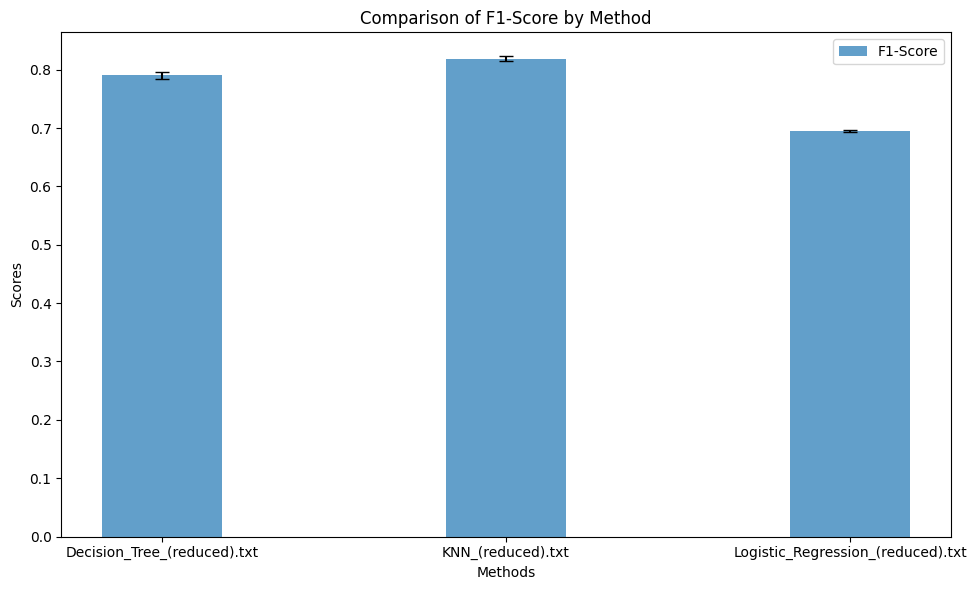

In [44]:
import numpy as np
import matplotlib.pyplot as plt

metrics = ["f1"] 
means = {metric: [np.mean(results[i]) for i, model in enumerate(models)] for metric in metrics}
stds = { metric: [np.std(results[i]) for i, model in enumerate(models)] for metric in metrics}

x = np.arange(len(models)) 
width = 0.35 

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(x,means["f1"], width, yerr=stds["f1"], capsize=5, label="F1-Score", alpha=0.7)

ax.set_xlabel('Methods')
ax.set_ylabel('Scores')
ax.set_title('Comparison of F1-Score by Method')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

plt.tight_layout()
plt.show()

In [43]:
from scipy.stats import ttest_rel
import itertools
import numpy as np 


model_to_index = {name: i for i, name in enumerate(models)}
testT = list(itertools.combinations(models, 2))

num_comparisons = len(testT)
alpha = 0.005
adjusted_alpha = alpha / num_comparisons

print(f"\nMétrica: {metrics}")
for method1, method2 in testT:
    idx1 = model_to_index[method1]
    idx2 = model_to_index[method2]
    
    scores1 = results[idx1] 
    scores2 = results[idx2] 
    
    t_stat, p_value = ttest_rel(scores1, scores2)
    p_value_corrected = p_value * num_comparisons

    print(f"{method1} vs {method2}:")
    print(f"t = {t_stat:.4f}, p = {p_value:.4e} (corrigido: {p_value_corrected:.4e})")
    if p_value_corrected < alpha: 
        print("-> Diferença estatisticamente significativa! (p_corrigido < 0.05)")
    else:
        print("-> Não há diferença estatisticamente significativa.")


Métrica: ['f1']
Decision_Tree_(reduced).txt vs KNN_(reduced).txt:
t = -18.4373, p = 5.0920e-05 (corrigido: 1.5276e-04)
-> Diferença estatisticamente significativa! (p_corrigido < 0.05)
Decision_Tree_(reduced).txt vs Logistic_Regression_(reduced).txt:
t = 30.5027, p = 6.8817e-06 (corrigido: 2.0645e-05)
-> Diferença estatisticamente significativa! (p_corrigido < 0.05)
KNN_(reduced).txt vs Logistic_Regression_(reduced).txt:
t = 76.1936, p = 1.7782e-07 (corrigido: 5.3346e-07)
-> Diferença estatisticamente significativa! (p_corrigido < 0.05)
